In [2]:
# ── BLOCK 1: Import Libraries & Load Data ──
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix, 
                             f1_score, accuracy_score, roc_auc_score)
from imblearn.over_sampling import SMOTE

# Load original dataset
df = pd.read_csv("../data/creditcard.csv")

# Recreate risk tiers
def assign_risk_tier(amount):
    if amount <= 22:
        return 'Low'
    elif amount <= 77:
        return 'Medium'
    elif amount <= 500:
        return 'High'
    else:
        return 'Critical'

df['Risk_Tier'] = df['Amount'].apply(assign_risk_tier)

# Save it properly this time
df.to_csv("../data/creditcard_with_tiers.csv", index=False)

print("Dataset loaded and risk tiers created!")
print(f"Shape: {df.shape}")

Dataset loaded and risk tiers created!
Shape: (284807, 32)


In [3]:
# ── BLOCK 2: Prepare Data for Modelling ──

# Step 1: Separate features (X) and target (y)
X = df.drop(columns=['Class', 'Risk_Tier'])
y = df['Class']

# Keep risk tiers separately for later
risk_tiers = df['Risk_Tier']

# Step 2: Scale the Amount column
# (V1-V28 are already scaled from PCA, but Amount and Time are not)
scaler = StandardScaler()
X['Amount'] = scaler.fit_transform(X[['Amount']])
X['Time'] = scaler.fit_transform(X[['Time']])

# Step 3: Split into train and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("Data preparation complete!")
print(f"Training set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")
print(f"Fraud cases in training: {y_train.sum()}")
print(f"Fraud cases in test: {y_test.sum()}")

Data preparation complete!
Training set size: (227845, 30)
Test set size: (56962, 30)
Fraud cases in training: 394
Fraud cases in test: 98


In [4]:
# ── BLOCK 3: Fix Class Imbalance with SMOTE ──

print("Before SMOTE:")
print(f"Normal transactions: {sum(y_train==0)}")
print(f"Fraud transactions: {sum(y_train==1)}")

# Apply SMOTE - creates synthetic fraud examples
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print("\nAfter SMOTE:")
print(f"Normal transactions: {sum(y_train_balanced==0)}")
print(f"Fraud transactions: {sum(y_train_balanced==1)}")
print(f"\nNew training set size: {X_train_balanced.shape}")

Before SMOTE:
Normal transactions: 227451
Fraud transactions: 394

After SMOTE:
Normal transactions: 227451
Fraud transactions: 227451

New training set size: (454902, 30)


In [5]:
# ── BLOCK 4: Train Baseline Model ──

print("Training Baseline Model...")

# Create and train the model
baseline_model = LogisticRegression(max_iter=1000, random_state=42)
baseline_model.fit(X_train_balanced, y_train_balanced)

print("✅ Baseline model trained successfully!")

# Make predictions on the TEST set
y_pred_baseline = baseline_model.predict(X_test)
y_pred_proba_baseline = baseline_model.predict_proba(X_test)[:, 1]

print("\n=== BASELINE MODEL RESULTS ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_baseline):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred_baseline):.4f}")
print(f"ROC-AUC:  {roc_auc_score(y_test, y_pred_proba_baseline):.4f}")
print("\nDetailed Report:")
print(classification_report(y_test, y_pred_baseline, 
      target_names=['Normal', 'Fraud']))

Training Baseline Model...
✅ Baseline model trained successfully!

=== BASELINE MODEL RESULTS ===
Accuracy: 0.9743
F1 Score: 0.1094
ROC-AUC:  0.9698

Detailed Report:
              precision    recall  f1-score   support

      Normal       1.00      0.97      0.99     56864
       Fraud       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962



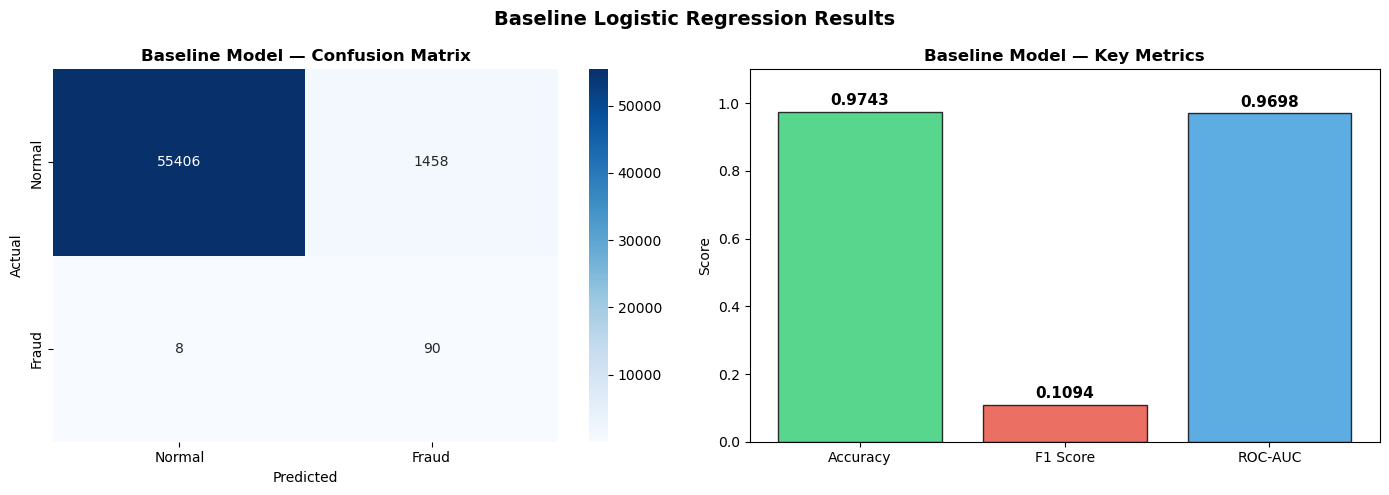

Chart saved!


In [6]:
# ── BLOCK 5: Visualise Baseline Results ──

# Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1 - Confusion Matrix
cm = confusion_matrix(y_test, y_pred_baseline)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Fraud'],
            yticklabels=['Normal', 'Fraud'],
            ax=axes[0])
axes[0].set_title('Baseline Model — Confusion Matrix', 
                   fontweight='bold', fontsize=12)
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# Plot 2 - Results Summary Bar Chart
metrics = ['Accuracy', 'F1 Score', 'ROC-AUC']
values = [0.9743, 0.1094, 0.9698]
colors = ['#2ecc71', '#e74c3c', '#3498db']

axes[1].bar(metrics, values, color=colors, edgecolor='black', alpha=0.8)
axes[1].set_title('Baseline Model — Key Metrics', 
                   fontweight='bold', fontsize=12)
axes[1].set_ylim(0, 1.1)
axes[1].set_ylabel('Score')
for i, (m, v) in enumerate(zip(metrics, values)):
    axes[1].text(i, v + 0.02, f'{v:.4f}', ha='center', 
                fontweight='bold', fontsize=11)

plt.suptitle('Baseline Logistic Regression Results', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("../results/baseline_results.png")
plt.show()
print("Chart saved!")

In [7]:
# ── BLOCK 6: Save Baseline Results ──
import json

baseline_results = {
    'model': 'Baseline Logistic Regression',
    'accuracy': 0.9743,
    'f1_score': 0.1094,
    'roc_auc': 0.9698,
    'fraud_recall': 0.92,
    'fraud_precision': 0.06,
    'true_negatives': 55406,
    'false_positives': 1458,
    'false_negatives': 8,
    'true_positives': 90
}

with open("../results/baseline_results.json", 'w') as f:
    json.dump(baseline_results, f, indent=4)

print("✅ Results saved!")
print()
print("=== WHAT TO SHOW DR. SYED TOMORROW ===")
print()
print("1. Data exploration — 284,807 transactions, 0.17% fraud rate")
print("2. Risk matrix — Critical tier has 6x higher fraud rate than Medium")
print("3. Baseline model trained and evaluated:")
print("   - Catches 90/98 frauds (92% recall)")
print("   - BUT raises 1,458 false alarms")
print("   - F1 score only 0.11 — shows pure classification is not enough")
print("4. THIS is why L2D with risk-sensitive weighting is needed")
print("   — a smarter deferral system beats blanket flagging")

✅ Results saved!

=== WHAT TO SHOW DR. SYED TOMORROW ===

1. Data exploration — 284,807 transactions, 0.17% fraud rate
2. Risk matrix — Critical tier has 6x higher fraud rate than Medium
3. Baseline model trained and evaluated:
   - Catches 90/98 frauds (92% recall)
   - BUT raises 1,458 false alarms
   - F1 score only 0.11 — shows pure classification is not enough
4. THIS is why L2D with risk-sensitive weighting is needed
   — a smarter deferral system beats blanket flagging
